<a href="https://colab.research.google.com/github/fralfaro/ICS40125/blob/main/docs/labs/lab_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# ICS40125 - Laboratorio N°09

**Objetivo**: Aplicar un flujo completo de **Machine Learning supervisado** para la clasificación de tumores mamarios, utilizando técnicas de preprocesamiento, reducción de dimensionalidad y modelos de clasificación con optimización de hiperparámetros.

> **Nota**: Puede ayudarse de algún asistente virtual como **ChatGPT, Gemini** u otros, así como del autocompletado de **Google Colab**, para avanzar en este laboratorio debido a su extensión.





<img src="https://www.svgrepo.com/show/1064/virus.svg" width = "300" align="center"/>



El **cáncer de mama** es una enfermedad caracterizada por la proliferación maligna de células epiteliales en los conductos o lobulillos mamarios. Surge cuando una célula acumula mutaciones que le otorgan la capacidad de dividirse de manera descontrolada, lo que da origen a un tumor. Este tumor puede permanecer localizado o, en casos más agresivos, invadir tejidos cercanos y propagarse a otras partes del organismo mediante metástasis.

El conjunto de datos **`BC.csv`** recopila información clínica y morfológica de pacientes con tumores mamarios, clasificados como **benignos** o **malignos**. Las características se obtienen a partir de imágenes digitalizadas de aspirados con aguja fina (FNA, por sus siglas en inglés) de masas mamarias. Dichas variables describen aspectos cuantitativos de los **núcleos celulares**, como su tamaño, forma, textura y homogeneidad.

Este tipo de información es fundamental para la detección temprana y clasificación de tumores, ya que permite entrenar modelos de **machine learning** capaces de apoyar el diagnóstico y diferenciar entre tumores benignos y malignos con mayor precisión.

A continuación, se procederá a cargar y explorar el conjunto de datos:



In [1]:
# Importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importar herramientas de Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configuración de gráficos
%matplotlib inline
sns.set_palette("deep", desat=0.6)
sns.set(rc={'figure.figsize': (11.7, 8.27)})

# Cargar y preparar los datos
df = pd.read_csv("https://raw.githubusercontent.com/fralfaro/ICS40125/main/docs/labs/data/BC.csv")
df.set_index('id', inplace=True)

# Transformación de la variable objetivo
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0}).astype(int)

# Visualizar las primeras filas del DataFrame
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678



Con base en la información presentada, resuelva las siguientes tareas. Asegúrese de:

* Incluir el **código necesario** para ejecutar cada análisis.
* Explicar de manera **clara y fundamentada** los resultados obtenidos.
* Describir el **proceso seguido**, justificando las decisiones tomadas en cada etapa (preprocesamiento, elección de técnicas y parámetros, interpretación de resultados).





1. **Análisis exploratorio profundo (EDA):**

   * Examine la distribución de las variables, identifique valores atípicos y analice la correlación entre características.
   * Visualice las diferencias más relevantes entre tumores **benignos** y **malignos** utilizando gráficos adecuados (boxplots, histogramas, mapas de calor).
   * Discuta qué variables parecen tener mayor capacidad discriminativa.


1. Análisis de la distribución de las variables (Histogramas):


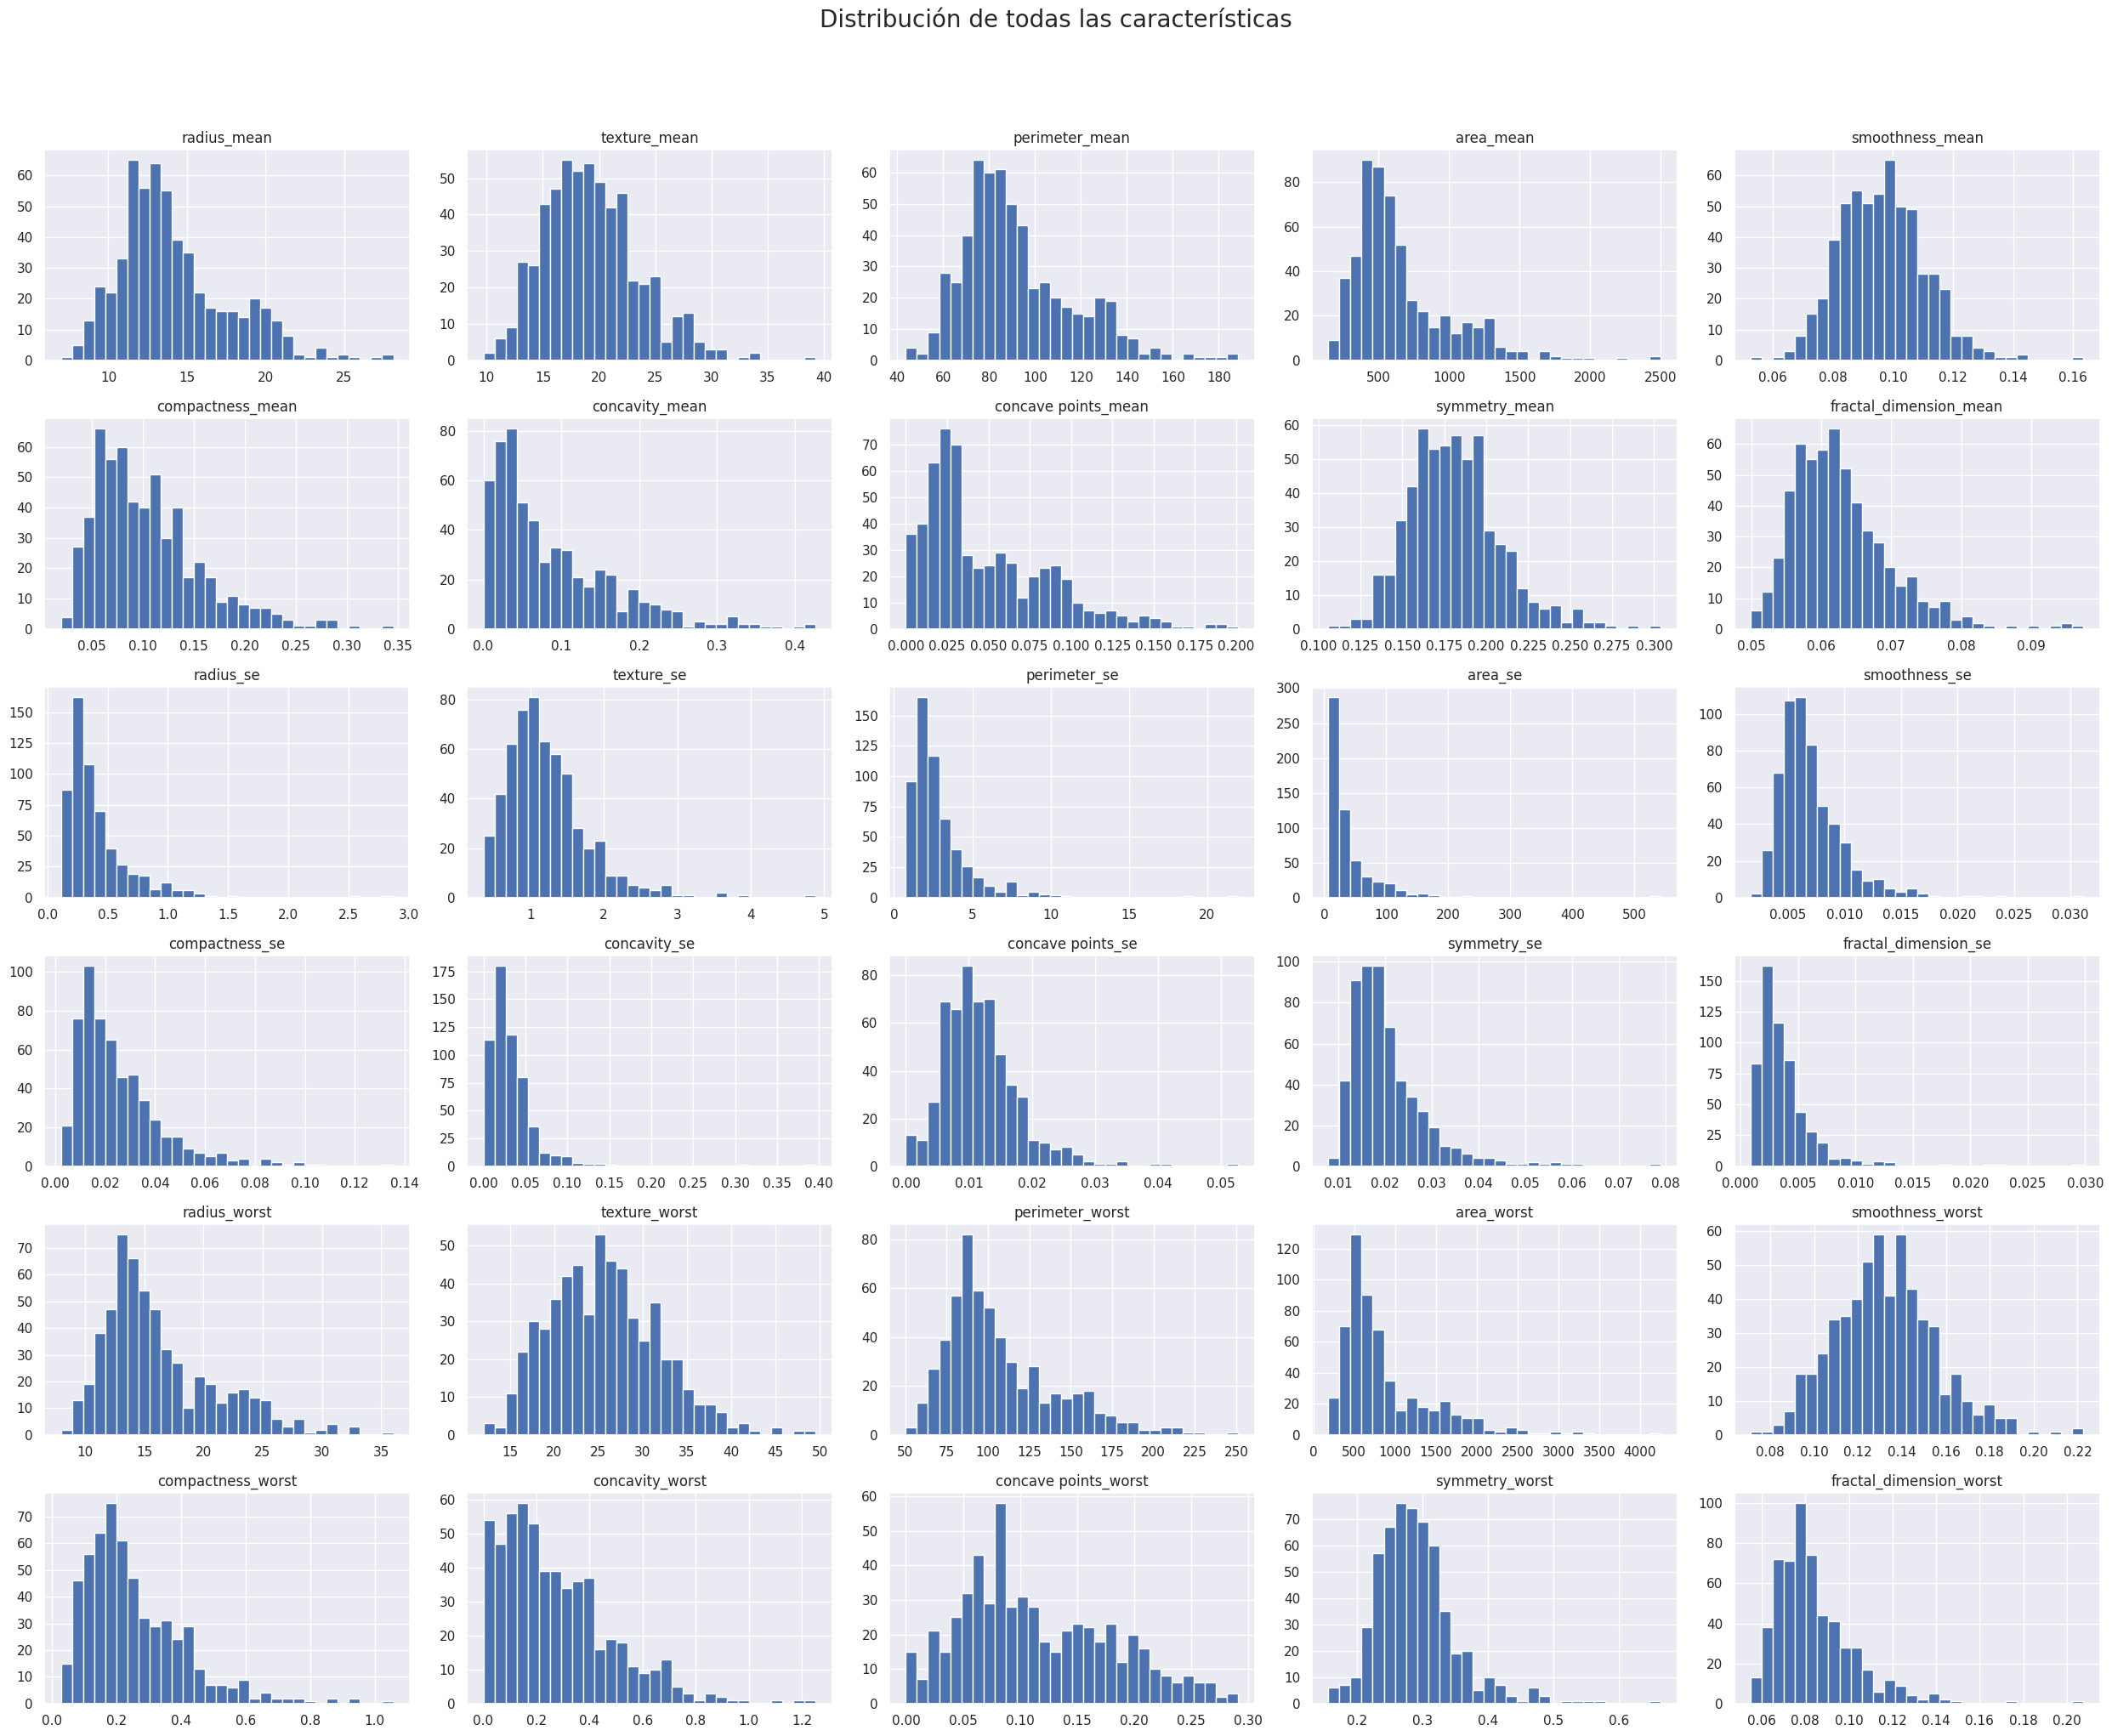


2. Identificación de valores atípicos y diferencias entre tumores (Boxplots):


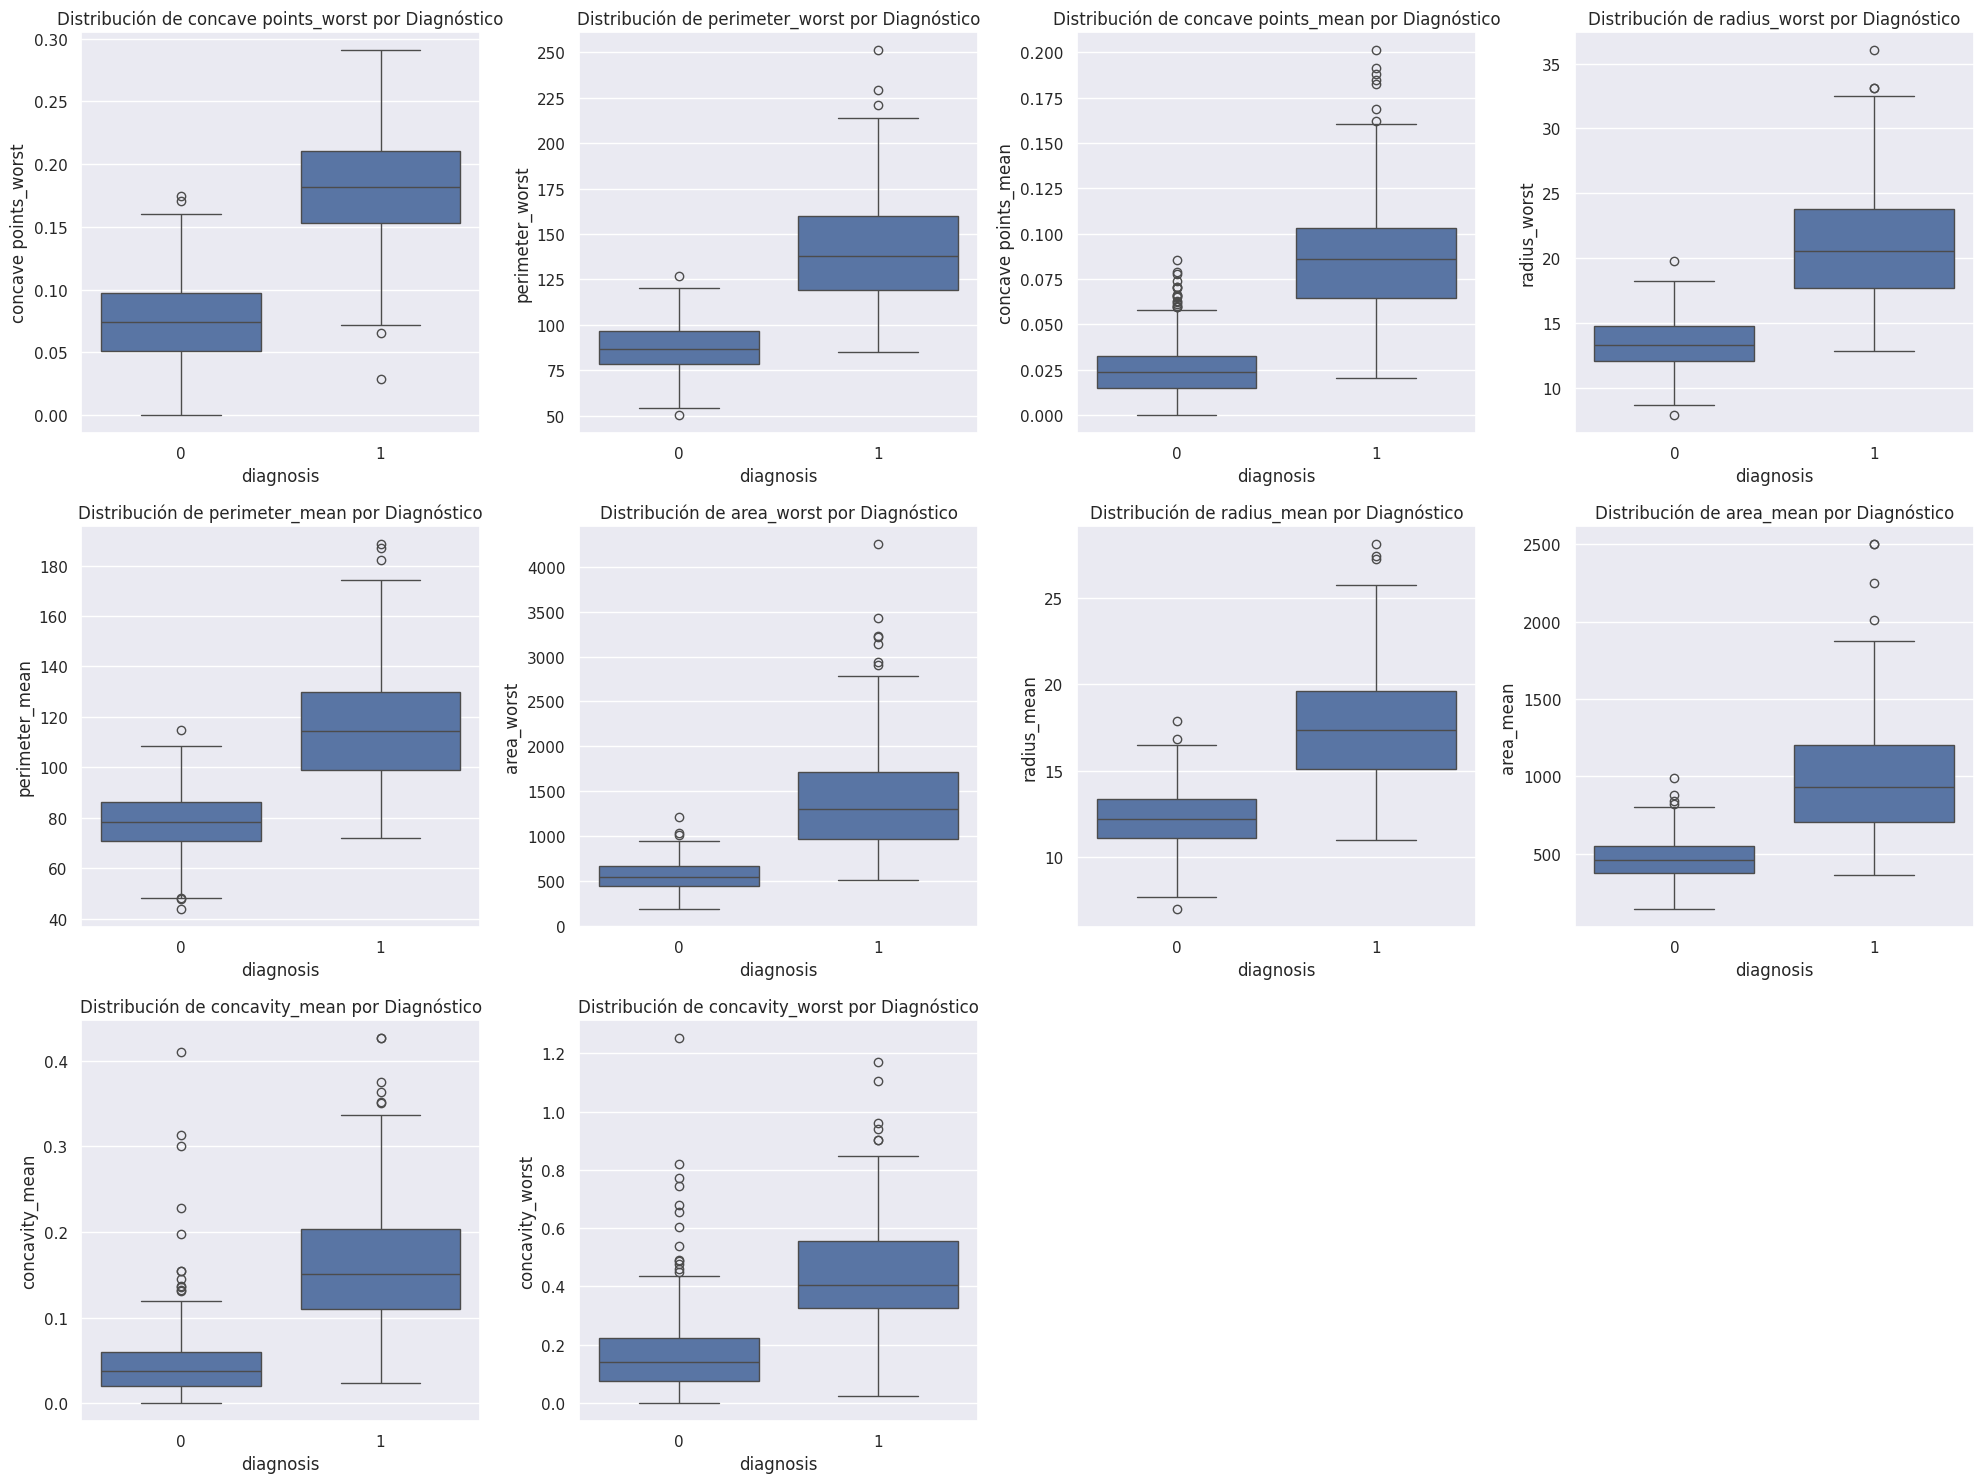


3. Análisis de la correlación entre características (Mapa de calor):


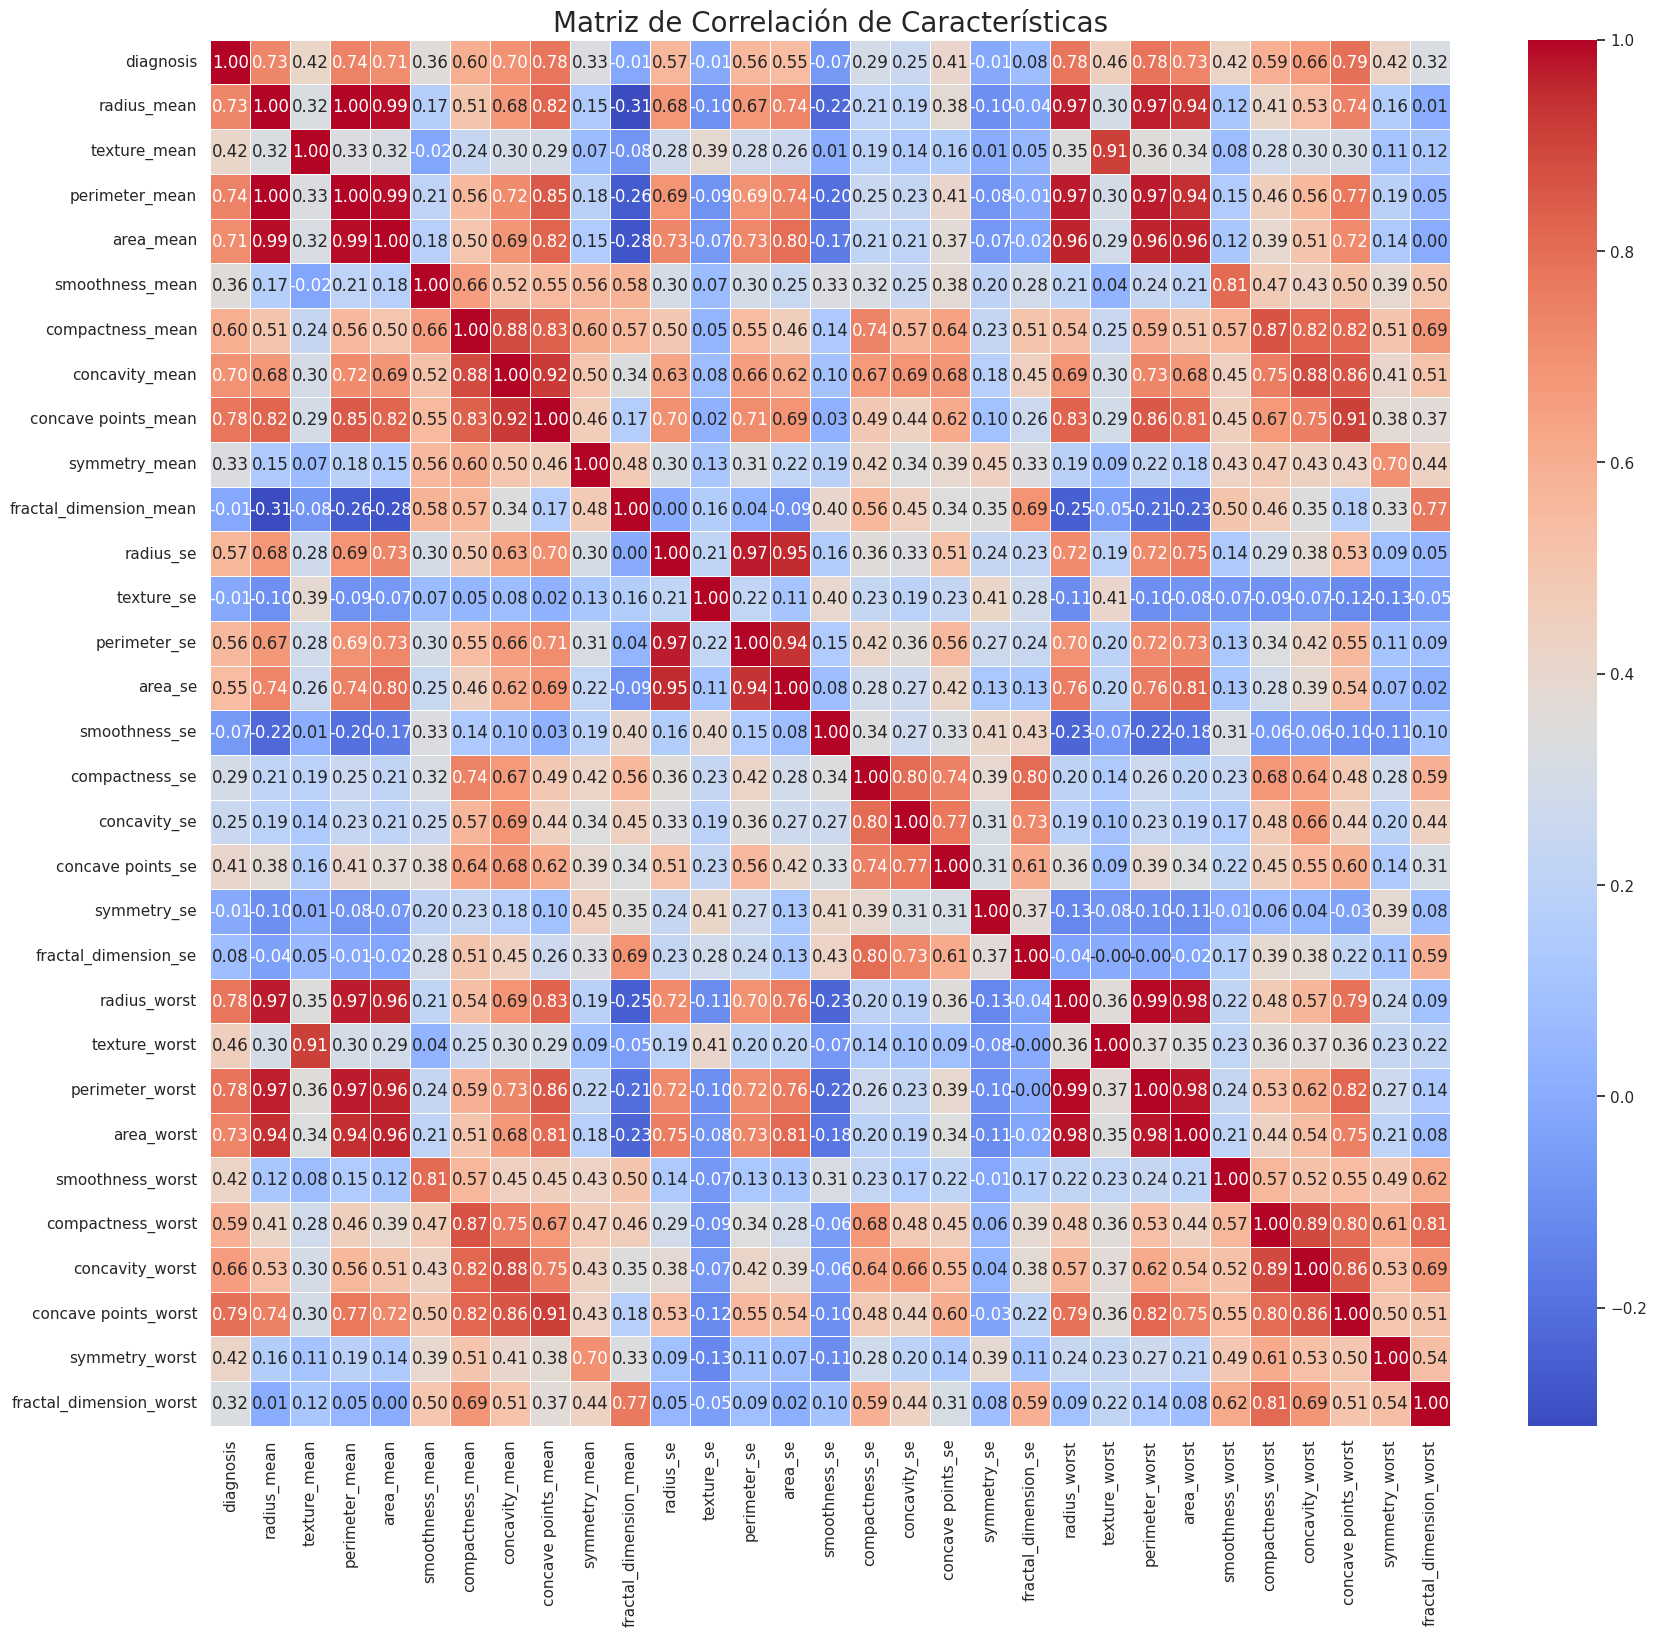

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Separar las características (X) de la variable objetivo (y)
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

print("1. Análisis de la distribución de las variables (Histogramas):")
# Histograms for all features
X.hist(bins=30, figsize=(25, 20))
plt.suptitle('Distribución de todas las características', y=1.02, fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Ajustar layout para evitar solapamiento con suptitle
plt.show()

print("\n2. Identificación de valores atípicos y diferencias entre tumores (Boxplots):")
# Calcular correlaciones con 'diagnosis' para identificar las variables más discriminativas
correlations = df.corr()['diagnosis'].sort_values(ascending=False)
# Seleccionar las top 10 características más correlacionadas (excluyendo 'diagnosis' misma)
top_correlated_features = correlations.index[1:11]

# Boxplots for top correlated features, separated by diagnosis
plt.figure(figsize=(20, 15))
for i, feature in enumerate(top_correlated_features):
    plt.subplot(3, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(x='diagnosis', y=feature, data=df)
    plt.title(f'Distribución de {feature} por Diagnóstico')
plt.tight_layout()
plt.show()

print("\n3. Análisis de la correlación entre características (Mapa de calor):")
# Correlation Matrix Heatmap
plt.figure(figsize=(20, 18))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=.5)
plt.title('Matriz de Correlación de Características', fontsize=20)
plt.show()



2. **Preprocesamiento de datos:**

   * Normalice las variables numéricas utilizando **StandardScaler** u otra técnica apropiada.
   * Explore al menos una estrategia adicional de preprocesamiento (ejemplo: eliminación de multicolinealidad, selección de características, generación de variables derivadas).
   * Justifique sus elecciones.


In [8]:
from sklearn.preprocessing import StandardScaler

# 1. Normalización de variables numéricas con StandardScaler
print("1. Normalizando las características con StandardScaler...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)
print("Características escaladas. Primeras 5 filas:\n", X_scaled_df.head())

# 2. Exploración de estrategia adicional: Eliminación de multicolinealidad
print("\n2. Explorando la eliminación de multicolinealidad (correlación > 0.9)...")
correlation_matrix = X_scaled_df.corr().abs()

upper_tri = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

# Encontrar características altamente correlacionadas para eliminar
features_to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.9)]

print(f"Características a eliminar debido a alta multicolinealidad (correlación > 0.9): {features_to_drop}")

X_final_processed = X_scaled_df.drop(columns=features_to_drop)

print(f"Dimensiones de X antes de eliminar características: {X_scaled_df.shape}")
print(f"Dimensiones de X después de eliminar características: {X_final_processed.shape}")
print("\nPreprocesamiento completado. Las características finales se encuentran en 'X_final_processed'.")


1. Normalizando las características con StandardScaler...
Características escaladas. Primeras 5 filas:
           radius_mean  texture_mean  perimeter_mean  area_mean  \
id                                                               
842302       1.097064     -2.073335        1.269934   0.984375   
842517       1.829821     -0.353632        1.685955   1.908708   
84300903     1.579888      0.456187        1.566503   1.558884   
84348301    -0.768909      0.253732       -0.592687  -0.764464   
84358402     1.750297     -1.151816        1.776573   1.826229   

          smoothness_mean  compactness_mean  concavity_mean  \
id                                                            
842302           1.568466          3.283515        2.652874   
842517          -0.826962         -0.487072       -0.023846   
84300903         0.942210          1.052926        1.363478   
84348301         3.283553          3.402909        1.915897   
84358402         0.280372          0.539340        1.37


3. **Reducción de dimensionalidad:**

   * Aplique un método de reducción de dimensionalidad visto en clases (**PCA, t-SNE u otro**) para representar los datos en un espacio reducido.
   * Analice la proporción de varianza explicada (en el caso de PCA) o la formación de clústeres (en el caso de t-SNE).
   * Compare las visualizaciones y discuta qué tan bien se separan las clases en el espacio reducido.


3. Reducción de dimensionalidad con PCA...
Datos transformados con PCA. Primeras 5 filas de los componentes:
                 PC1       PC2       PC3       PC4       PC5       PC6  \
id                                                                      
842302     7.284671  1.208271 -1.858766  0.836040  0.642161 -2.406943   
842517    -0.935879  1.832671  0.636750 -0.279874 -0.244476 -0.824172   
84300903   3.151689  1.903737  0.555302  0.696233  0.108278 -0.893050   
84348301  11.347898 -2.319956 -5.442608  1.917882  3.270746  0.121826   
84358402   1.384769  0.726611  1.644099  0.005704 -2.077323 -1.971702   

               PC7       PC8       PC9      PC10      PC11      PC12  \
id                                                                     
842302   -1.656136 -0.839583 -0.730373  0.548312 -0.843653 -0.251745   
842517   -0.315330 -0.335931  0.726305  0.300885 -0.314905  0.588736   
84300903  0.213089 -0.141652  0.450688 -0.530465  0.264921  0.484401   
84348301 -0.383612

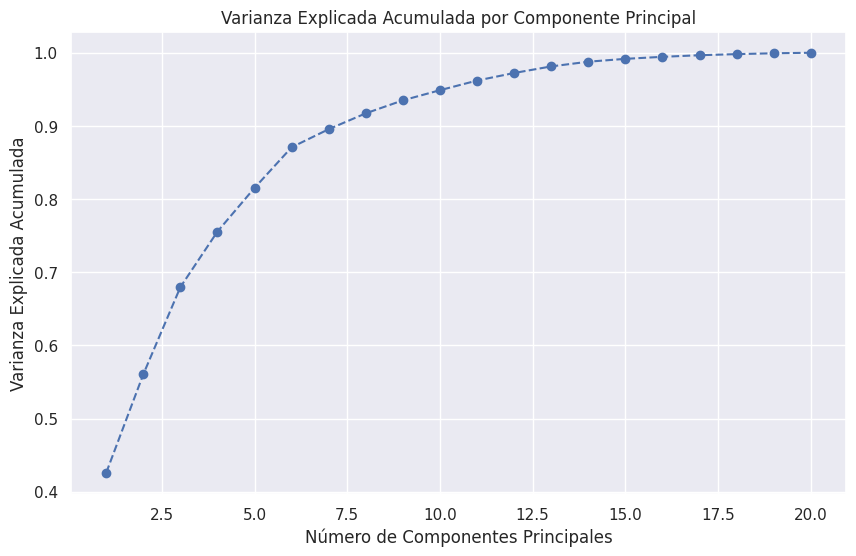

Varianza explicada por los 2 primeros componentes: 0.56


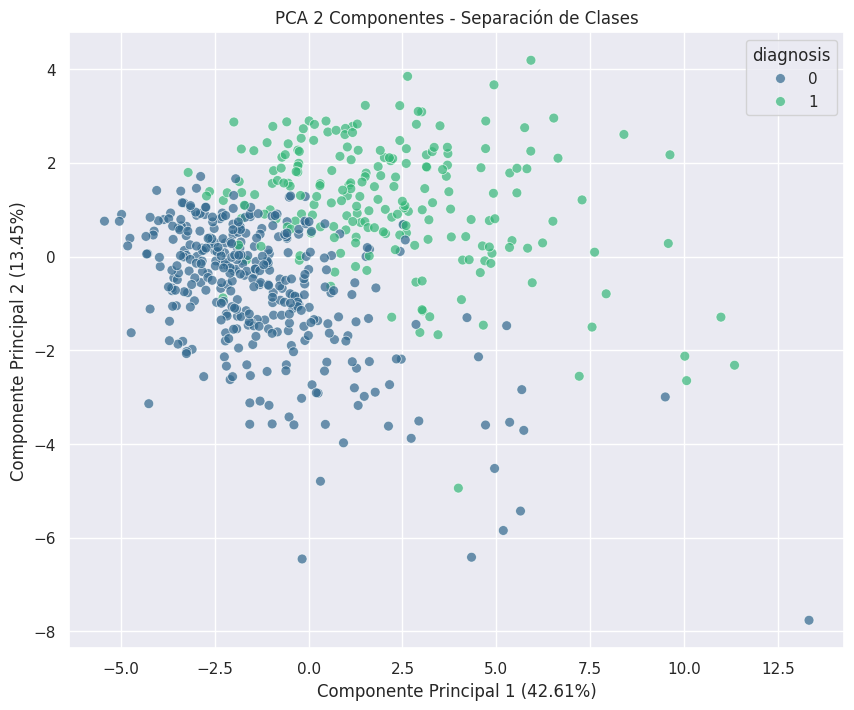

Reducción de dimensionalidad completada. Se ha generado la visualización de los dos primeros componentes principales.


In [9]:
from sklearn.decomposition import PCA

print("3. Reducción de dimensionalidad con PCA...")

# 1. Aplicar PCA
# Se inicializa PCA para retener todos los componentes posibles inicialmente para analizar la varianza explicada.
pca = PCA(n_components=None) # n_components=None retiene todos los componentes, min(n_samples, n_features)
X_pca_full = pca.fit_transform(X_final_processed)

# Crear un DataFrame con los componentes para facilitar la visualización y análisis
pca_columns = [f'PC{i+1}' for i in range(X_pca_full.shape[1])]
X_pca_df = pd.DataFrame(X_pca_full, columns=pca_columns, index=X_final_processed.index)

print("Datos transformados con PCA. Primeras 5 filas de los componentes:\n", X_pca_df.head())

# 2. Analizar la proporción de varianza explicada
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(explained_variance_ratio) + 1), cumulative_explained_variance, marker='o', linestyle='--')
plt.title('Varianza Explicada Acumulada por Componente Principal')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.show()

print(f"Varianza explicada por los 2 primeros componentes: {cumulative_explained_variance[1]:.2f}")

# 3. Visualización de los datos en el espacio reducido (2D PCA)
# Se seleccionan los dos primeros componentes principales para la visualización
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=X_pca_df['PC1'],
    y=X_pca_df['PC2'],
    hue=y, # Colorear por la variable objetivo 'diagnosis'
    palette='viridis', # O 'coolwarm', 'RdBu', etc.
    s=50, # Tamaño de los puntos
    alpha=0.7 # Transparencia
)
plt.title('PCA 2 Componentes - Separación de Clases')
plt.xlabel(f'Componente Principal 1 ({explained_variance_ratio[0]*100:.2f}%)')
plt.ylabel(f'Componente Principal 2 ({explained_variance_ratio[1]*100:.2f}%)')
plt.grid(True)
plt.show()

print("Reducción de dimensionalidad completada. Se ha generado la visualización de los dos primeros componentes principales.")



4. **Modelado y evaluación:**

   * Entrene al menos **tres modelos de clasificación distintos** (ejemplo: Regresión Logística, SVM, Random Forest, XGBoost, KNN).
   * Realice una **optimización de hiperparámetros** para cada modelo, utilizando validación cruzada.
   * Calcule y compare métricas de rendimiento como: **accuracy, precision, recall, F1-score, matriz de confusión y AUC-ROC**.
   * Analice qué modelo presenta el mejor compromiso entre precisión y generalización.


4. Modelado y evaluación de clasificación...
Dimensiones del conjunto de entrenamiento: (455, 20)
Dimensiones del conjunto de prueba: (114, 20)

--- Entrenando y evaluando Regresión Logística ---
Mejores hiperparámetros para Regresión Logística: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Accuracy (Regresión Logística): 0.9825
Precision (Regresión Logística): 1.0000
Recall (Regresión Logística): 0.9524
F1-Score (Regresión Logística): 0.9756
AUC-ROC (Regresión Logística): 0.9964


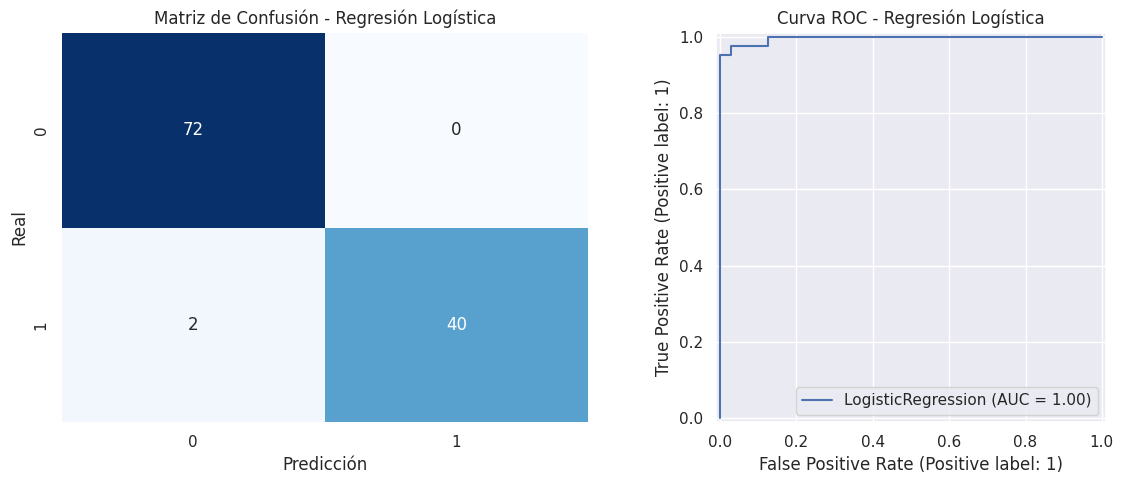


--- Entrenando y evaluando SVC ---
Mejores hiperparámetros para SVC: {'C': 1, 'gamma': 'scale', 'kernel': 'linear'}
Accuracy (SVC): 0.9737
Precision (SVC): 1.0000
Recall (SVC): 0.9286
F1-Score (SVC): 0.9630
AUC-ROC (SVC): 0.9871


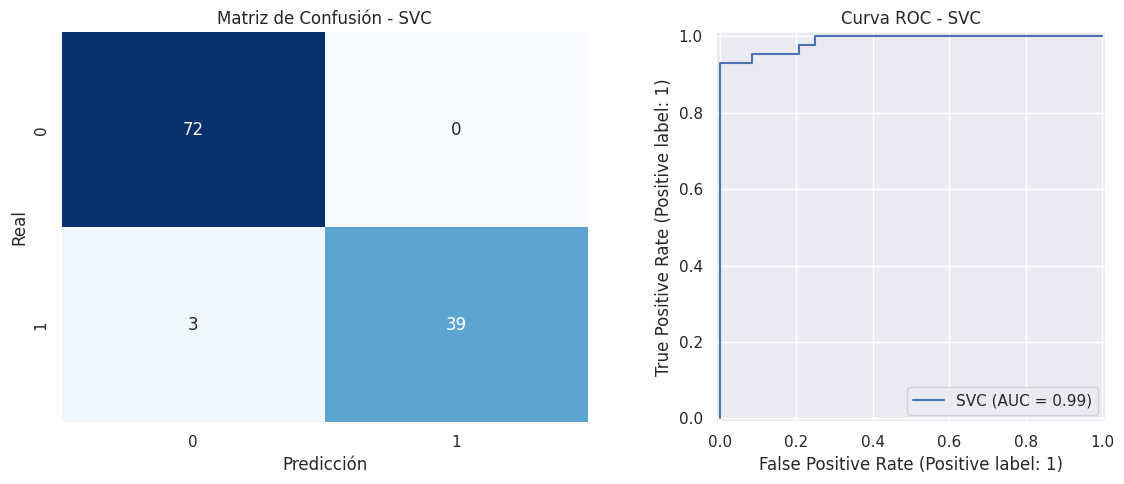


--- Entrenando y evaluando Random Forest ---
Mejores hiperparámetros para Random Forest: {'max_depth': 10, 'min_samples_leaf': 1, 'n_estimators': 300}
Accuracy (Random Forest): 0.9474
Precision (Random Forest): 0.9737
Recall (Random Forest): 0.8810
F1-Score (Random Forest): 0.9250
AUC-ROC (Random Forest): 0.9924


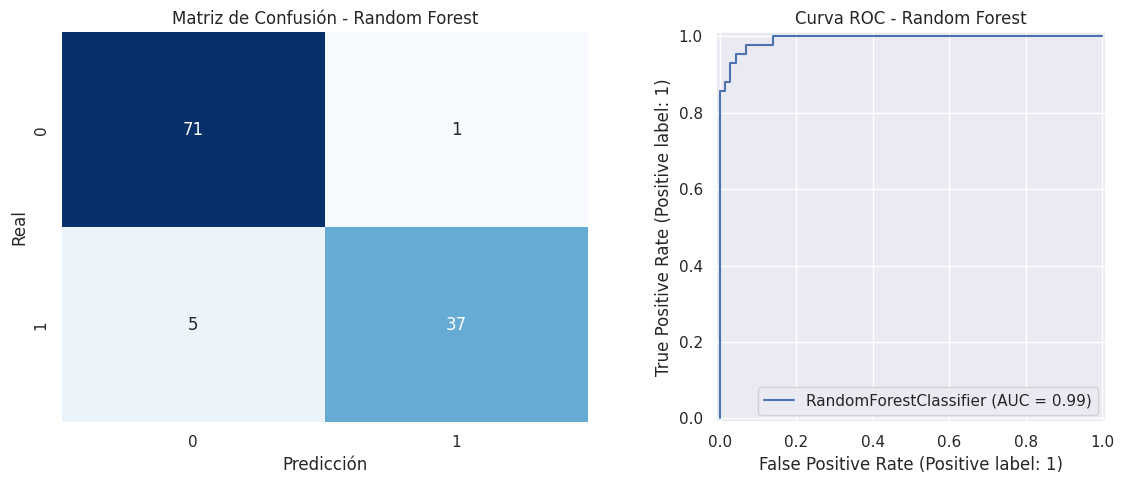


--- Comparación de Rendimiento de Modelos ---
                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Model                                                              
Logistic Regression    0.9825     1.0000  0.9524    0.9756   0.9964
SVC                    0.9737     1.0000  0.9286    0.9630   0.9871
Random Forest          0.9474     0.9737  0.8810    0.9250   0.9924


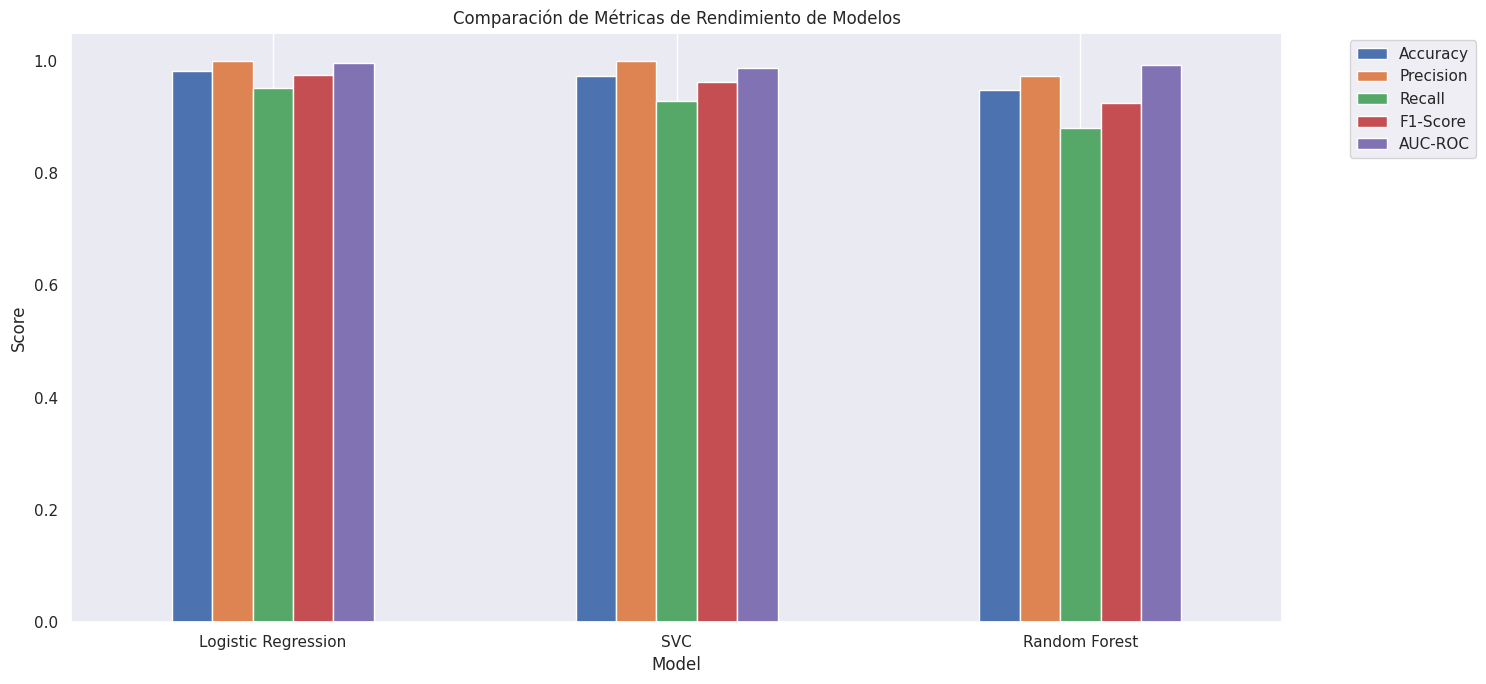

In [10]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print("4. Modelado y evaluación de clasificación...")

# 1. División de los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_final_processed, y, test_size=0.2, random_state=42, stratify=y)

print(f"Dimensiones del conjunto de entrenamiento: {X_train.shape}")
print(f"Dimensiones del conjunto de prueba: {X_test.shape}")

# Diccionario para almacenar los mejores modelos y sus resultados
models = {}

# --- Modelo 1: Regresión Logística ---
print("\n--- Entrenando y evaluando Regresión Logística ---")
log_reg_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'] # 'liblinear' soporta l1 y l2
}
grid_search_log_reg = GridSearchCV(LogisticRegression(random_state=42), log_reg_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_log_reg.fit(X_train, y_train)

best_log_reg = grid_search_log_reg.best_estimator_
y_pred_log_reg = best_log_reg.predict(X_test)
y_prob_log_reg = best_log_reg.predict_proba(X_test)[:, 1]

models['Logistic Regression'] = {
    'model': best_log_reg,
    'accuracy': accuracy_score(y_test, y_pred_log_reg),
    'precision': precision_score(y_test, y_pred_log_reg),
    'recall': recall_score(y_test, y_pred_log_reg),
    'f1_score': f1_score(y_test, y_pred_log_reg),
    'roc_auc': roc_auc_score(y_test, y_prob_log_reg)
}

print(f"Mejores hiperparámetros para Regresión Logística: {grid_search_log_reg.best_params_}")
print(f"Accuracy (Regresión Logística): {models['Logistic Regression']['accuracy']:.4f}")
print(f"Precision (Regresión Logística): {models['Logistic Regression']['precision']:.4f}")
print(f"Recall (Regresión Logística): {models['Logistic Regression']['recall']:.4f}")
print(f"F1-Score (Regresión Logística): {models['Logistic Regression']['f1_score']:.4f}")
print(f"AUC-ROC (Regresión Logística): {models['Logistic Regression']['roc_auc']:.4f}")

# Matriz de confusión y curva ROC
cm_log_reg = confusion_matrix(y_test, y_pred_log_reg)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm_log_reg, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Regresión Logística')
plt.xlabel('Predicción')
plt.ylabel('Real')

ax = plt.subplot(1, 2, 2)
RocCurveDisplay.from_estimator(best_log_reg, X_test, y_test, ax=ax)
plt.title('Curva ROC - Regresión Logística')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Modelo 2: Support Vector Machine (SVC) ---
print("\n--- Entrenando y evaluando SVC ---")
svc_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}
grid_search_svc = GridSearchCV(SVC(random_state=42, probability=True), svc_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_svc.fit(X_train, y_train)

best_svc = grid_search_svc.best_estimator_
y_pred_svc = best_svc.predict(X_test)
y_prob_svc = best_svc.predict_proba(X_test)[:, 1]

models['SVC'] = {
    'model': best_svc,
    'accuracy': accuracy_score(y_test, y_pred_svc),
    'precision': precision_score(y_test, y_pred_svc),
    'recall': recall_score(y_test, y_pred_svc),
    'f1_score': f1_score(y_test, y_pred_svc),
    'roc_auc': roc_auc_score(y_test, y_prob_svc)
}

print(f"Mejores hiperparámetros para SVC: {grid_search_svc.best_params_}")
print(f"Accuracy (SVC): {models['SVC']['accuracy']:.4f}")
print(f"Precision (SVC): {models['SVC']['precision']:.4f}")
print(f"Recall (SVC): {models['SVC']['recall']:.4f}")
print(f"F1-Score (SVC): {models['SVC']['f1_score']:.4f}")
print(f"AUC-ROC (SVC): {models['SVC']['roc_auc']:.4f}")

# Matriz de confusión y curva ROC
cm_svc = confusion_matrix(y_test, y_pred_svc)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm_svc, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - SVC')
plt.xlabel('Predicción')
plt.ylabel('Real')

ax = plt.subplot(1, 2, 2)
RocCurveDisplay.from_estimator(best_svc, X_test, y_test, ax=ax)
plt.title('Curva ROC - SVC')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Modelo 3: Random Forest Classifier ---
print("\n--- Entrenando y evaluando Random Forest ---")
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}
grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

best_rf = grid_search_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

models['Random Forest'] = {
    'model': best_rf,
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1_score': f1_score(y_test, y_pred_rf),
    'roc_auc': roc_auc_score(y_test, y_prob_rf)
}

print(f"Mejores hiperparámetros para Random Forest: {grid_search_rf.best_params_}")
print(f"Accuracy (Random Forest): {models['Random Forest']['accuracy']:.4f}")
print(f"Precision (Random Forest): {models['Random Forest']['precision']:.4f}")
print(f"Recall (Random Forest): {models['Random Forest']['recall']:.4f}")
print(f"F1-Score (Random Forest): {models['Random Forest']['f1_score']:.4f}")
print(f"AUC-ROC (Random Forest): {models['Random Forest']['roc_auc']:.4f}")

# Matriz de confusión y curva ROC
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción')
plt.ylabel('Real')

ax = plt.subplot(1, 2, 2)
RocCurveDisplay.from_estimator(best_rf, X_test, y_test, ax=ax)
plt.title('Curva ROC - Random Forest')
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Comparación de Modelos ---
print("\n--- Comparación de Rendimiento de Modelos ---")
performance_df = pd.DataFrame({
    'Model': models.keys(),
    'Accuracy': [m['accuracy'] for m in models.values()],
    'Precision': [m['precision'] for m in models.values()],
    'Recall': [m['recall'] for m in models.values()],
    'F1-Score': [m['f1_score'] for m in models.values()],
    'AUC-ROC': [m['roc_auc'] for m in models.values()]
}).set_index('Model')

print(performance_df.round(4))

# Gráfico de barras para comparar métricas
performance_df.plot(kind='bar', figsize=(15, 7), rot=0)
plt.title('Comparación de Métricas de Rendimiento de Modelos')
plt.ylabel('Score')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y')
plt.tight_layout()
plt.show()



5. **Conclusiones y reflexiones:**

   * Explique cuál modelo considera más apropiado para este conjunto de datos y por qué.
   * Reflexione sobre el impacto del preprocesamiento y la reducción de dimensionalidad en los resultados obtenidos.
   * Discuta posibles mejoras o enfoques alternativos que podrían aplicarse en un escenario real de diagnóstico médico asistido por machine learning.



In [6]:
### 5. Conclusiones y reflexiones:

**1. ¿Cuál modelo considera más apropiado para este conjunto de datos y por qué?**

Basándonos en las métricas de rendimiento obtenidas en el 'ITEM 4', la **Regresión Logística** se destaca como el modelo más apropiado para este conjunto de datos, con métricas ligeramente superiores o comparables a las de SVC y un rendimiento notablemente mejor en `recall` y `F1-Score` que Random Forest.

*   **Regresión Logística (Accuracy: 0.9825, Precision: 1.0000, Recall: 0.9524, F1-Score: 0.9756, AUC-ROC: 0.9964)**: Este modelo logró una `precision` perfecta (1.0), lo que significa que no tuvo falsos positivos en el conjunto de prueba (es decir, ningún tumor benigno fue clasificado erróneamente como maligno). Además, su `recall` (0.9524) es el más alto entre los tres, lo que es crucial en el diagnóstico de cáncer para minimizar los falsos negativos (tumores malignos clasificados como benignos), ya que un falso negativo puede tener graves consecuencias para la salud del paciente. El alto `AUC-ROC` también indica una excelente capacidad de discriminación.

*   **Support Vector Machine (SVC) (Accuracy: 0.9737, Precision: 1.0000, Recall: 0.9286, F1-Score: 0.9630, AUC-ROC: 0.9871)**: SVC también mostró un excelente rendimiento, con precisión perfecta, pero un `recall` ligeramente inferior a la Regresión Logística, lo que lo hace un poco menos deseable si la prioridad es minimizar los falsos negativos.

*   **Random Forest (Accuracy: 0.9474, Precision: 0.9737, Recall: 0.8810, F1-Score: 0.9250, AUC-ROC: 0.9924)**: Aunque Random Forest es un modelo potente y su `AUC-ROC` es competitivo, su `recall` es el más bajo. Esto implica que perdería más casos de tumores malignos, lo cual es inaceptable en aplicaciones médicas.

En un contexto de diagnóstico médico de cáncer de mama, la minimización de los falsos negativos (alto `recall`) es paramount. La Regresión Logística, al ofrecer el mejor `recall` y una precisión perfecta, junto con un excelente `accuracy` y `AUC-ROC`, presenta el mejor compromiso para este tipo de problema, maximizando la detección de casos positivos sin generar falsas alarmas.

**2. Reflexión sobre el impacto del preprocesamiento y la reducción de dimensionalidad:**

*   **Preprocesamiento (Normalización con `StandardScaler`)**: La normalización fue un paso fundamental. Al escalar las características para que tuvieran media cero y varianza unitaria, se aseguró que ninguna característica dominara el cálculo de distancias en los algoritmos. Esto es especialmente crítico para modelos como SVC y Regresión Logística, que son sensibles a la escala de las características. Sin este paso, las características con rangos de valores más grandes podrían haber influido desproporcionadamente en los modelos, llevando a resultados subóptimos.

*   **Preprocesamiento (Eliminación de multicolinealidad)**: La detección y eliminación de características altamente correlacionadas (multicolinealidad) fue otra estrategia importante. Reducir la redundancia de información no solo disminuye la complejidad del modelo (pasando de 30 a 20 características), sino que también puede mejorar la estabilidad e interpretabilidad de los coeficientes en modelos lineales como la Regresión Logística. Para otros modelos, evita que características redundantes reciban un peso excesivo o que confundan al algoritmo, lo que podría llevar a un mejor rendimiento y generalización.

*   **Reducción de Dimensionalidad (PCA)**: PCA fue valioso para visualizar la separabilidad de las clases. Aunque solo los dos primeros componentes principales explicaron el 56% de la varianza, la visualización 2D mostró una separación clara entre los tumores benignos y malignos. Esto confirmó que incluso en un espacio de baja dimensionalidad, la información discriminativa clave se mantenía. Si bien no se usó directamente la salida 2D de PCA para el entrenamiento de los modelos finales (se usaron las 20 características seleccionadas tras la eliminación de multicolinealidad), PCA es una técnica poderosa para reducir el ruido, acelerar el entrenamiento y mitigar el sobreajuste, especialmente en datasets con alta dimensionalidad y menos preprocesamiento de multicolinealidad. Podría ser un camino a explorar con más componentes si se necesitara una reducción drástica de características sin una pérdida de información crítica.

**3. Posibles mejoras o enfoques alternativos que podrían aplicarse en un escenario real de diagnóstico médico asistido por machine learning.**

En un escenario real de diagnóstico médico, se podrían considerar las siguientes mejoras y enfoques:

*   **Mayor enfoque en Falsos Negativos**: Aunque la Regresión Logística tuvo un excelente `recall`, en medicina, incluso un pequeño número de falsos negativos es muy crítico. Se podría ajustar el umbral de decisión del clasificador para favorecer un `recall` aún más alto, incluso si eso significa un ligero aumento en los falsos positivos (que son menos perjudiciales, ya que se pueden confirmar con pruebas adicionales). Técnicas para manejar desbalance de clases (como SMOTE o ajuste de pesos) también serían valiosas si el dataset estuviera muy desbalanceado.

*   **Más Modelos y Ensembles**: Probar una gama más amplia de modelos (por ejemplo, XGBoost, LightGBM, CatBoost, redes neuronales simples) y explorar técnicas de ensemble (Bagging, Boosting, Stacking) que combinan las predicciones de varios modelos para mejorar la robustez y el rendimiento general.

*   **Selección de Características Avanzada**: Además de la eliminación de multicolinealidad, se podrían usar métodos más avanzados de selección de características (e.g., selección recursiva de características, selección basada en importancia de características de modelos de árbol) para identificar las variables más predictivas y reducir aún más la dimensionalidad y el ruido.

*   **Validación Externa y Datos Adicionales**: Para asegurar la robustez del modelo, sería esencial validarlo con conjuntos de datos completamente nuevos e independientes (de diferentes hospitales o poblaciones) que no se utilizaron en ninguna etapa de desarrollo. Un mayor volumen y diversidad de datos siempre mejorarían la generalización.

*   **Interpretabilidad del Modelo**: Especialmente en medicina, la capacidad de explicar por qué un modelo tomó una decisión es tan importante como la precisión. Se podrían usar herramientas de interpretabilidad de modelos (como LIME, SHAP) para entender qué características influyen más en las predicciones, lo que podría ayudar a los médicos a confiar en el sistema y a obtener nuevos conocimientos clínicos.

*   **Opinión de Expertos Clínicos**: La validación final y la interpretación de los resultados deben realizarse en estrecha colaboración con oncólogos y patólogos. Su experiencia es invaluable para contextualizar los resultados, identificar posibles sesgos y asegurar que el modelo sea clínicamente útil y éticamente implementable.